# 03 - Modeling

Order of attack per the project brief: simplest serious model first, complexity must
earn its keep. Decisions already made by Austin (logged in
`docs/assumptions_limitations.md`): prospective framing leads; missing values (only
the value-based pct features) are median-imputed in-pipeline with missing-indicator
flags.

## Leak post-mortem: how v1 of this notebook died

This notebook's first version, running on v1 features that included 28-day chronic
load and ACWR, produced **validation AUC 0.987 / AP 0.49** - on a 1.5%-prevalence
problem, with prospective features. Our own red-flag checklist (field guide:
"AUC > 0.9 here means suspect leakage first") triggered. The hunt, in order:

1. **Multi-day injury runs?** No - all 583 positives are isolated onset days
   (zero positives within 7 days of another).
2. **Athlete memorization?** No - athlete-grouped CV was equally inflated, and
   unseen athletes cannot be memorized.
3. **Feature autopsy.** Four long-window features (`km_28d`, `acwr`,
   `rest_days_14d`, `wow_km_change`) were NaN for **100% of injury rows** vs
   4-19% of healthy rows; XGBoost put 93% of its gain on a single
   missing-indicator flag. The model had learned "window failed its coverage
   gate = injury."
4. **Root cause (in the data, not the code):** the publishers removed all rows
   for >= 22 days before every injury; 98.9% of healthy rows have a neighbor 1
   day back (demonstrated in 02, section 2). Any window reaching past the row's
   own 7 days is systematically empty for positives only. Every possible handling
   of that emptiness - flags, imputation, zero-fill, or row-dropping (which would
   have deleted all 583 positives) - encodes the label.

Resolution (Austin's call): features rebuilt in 02 to use each row's own window
only - prospective = days t-1..t-6, symmetric for every row. Chronic load and
ACWR are documented as unbuildable on this dataset rather than quietly shipped.
Git history preserves v1.

## What this notebook does and deliberately does not do

- DOES: define the two dev/test splits, compare imbalance strategies, tune small
  grids for logistic regression and XGBoost on validation data, pick winners by a
  rule stated before looking at numbers.
- DOES NOT: touch the held-out test sets. 04 evaluates the winners there, once,
  against the full pre-registered battery in `docs/evaluation_design.md`.

**Pre-registered selection rule**: winner = highest validation average precision;
ties within 0.005 go to the simpler model.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import average_precision_score, roc_auc_score
from xgboost import XGBClassifier

RNG = 42
PROC = Path('../data/processed')
X = pd.read_csv(PROC / 'features_day.csv.gz')
FEATS = [c for c in X.columns if c.endswith('__pros')]
print(len(FEATS), 'prospective features |', X.shape[0], 'rows |',
      int(X.injury.sum()), 'positives')

12 prospective features | 42766 rows | 583 positives


## 1. The two dev/test splits

**Time-aware.** Cutoffs at the 60th/80th percentile of `Date`: train < T1,
validation T1..T2, test >= T2, with a 7-day purge after each boundary (rows there
share up to 6 of 7 window days with rows across the boundary - the random-split
leak in miniature).

**Athlete-grouped.** Deterministic, decided before any results: athletes sorted by
injury count descending, every 4th to test (~25%). Spreads injury-rich and
injury-free athletes across both sides - 11 of 74 athletes have zero positives, so
a random draw could hand test almost none. GroupKFold(4) inside dev for selection.

In [2]:
T1, T2 = X.Date.quantile([.6, .8]).astype(int)
PURGE = 7
ta_train = X[X.Date < T1]
ta_val   = X[(X.Date >= T1 + PURGE) & (X.Date < T2)]
ta_test  = X[X.Date >= T2 + PURGE]          # NOT USED in this notebook
purged = len(X) - len(ta_train) - len(ta_val) - len(ta_test)
print(f'cutoffs T1={T1} T2={T2} | purged {purged} boundary rows')
for name, d in [('train', ta_train), ('val', ta_val), ('test (locked)', ta_test)]:
    print(f'  {name:14s} {len(d):6,} rows  {int(d.injury.sum()):3d} pos  '
          f'({100*d.injury.mean():.2f}%)  {d["Athlete ID"].nunique()} athletes')

counts = X.groupby('Athlete ID').injury.sum().sort_values(ascending=False)
order = counts.index.to_numpy()
test_ath = set(order[3::4])
dev_ath  = set(order) - test_ath
gr_dev  = X[X['Athlete ID'].isin(dev_ath)]
gr_test = X[X['Athlete ID'].isin(test_ath)]  # NOT USED in this notebook
print(f'grouped: dev {len(dev_ath)} athletes / {int(gr_dev.injury.sum())} pos | '
      f'test {len(test_ath)} athletes / {int(gr_test.injury.sum())} pos')
assert not (dev_ath & test_ath)

cutoffs T1=1498 T2=2057 | purged 171 boundary rows
  train          25,652 rows  300 pos  (1.17%)  64 athletes
  val             8,481 rows  132 pos  (1.56%)  34 athletes
  test (locked)   8,462 rows  149 pos  (1.76%)  32 athletes
grouped: dev 56 athletes / 453 pos | test 18 athletes / 130 pos


## 2. Pipelines

One preprocessing recipe for both model families so any performance difference is
the model, not the plumbing: median imputer (train-fit, in-pipeline,
`add_indicator=True` - only the pct features have NaN, and their missingness is
value-based and symmetric), then a scaler. XGBoost could ingest NaN natively; not
used, to keep the comparison apples-to-apples (logged as an assumption).

In [3]:
def logit_pipe(C=1.0, class_weight='balanced'):
    return Pipeline([
        ('impute', SimpleImputer(strategy='median', add_indicator=True)),
        ('scale', StandardScaler()),
        ('clf', LogisticRegression(C=C, class_weight=class_weight,
                                   max_iter=2000, random_state=RNG)),
    ])

def xgb_pipe(max_depth=3, learning_rate=0.1, spw=1.0):
    return Pipeline([
        ('impute', SimpleImputer(strategy='median', add_indicator=True)),
        ('clf', XGBClassifier(n_estimators=300, max_depth=max_depth,
                              learning_rate=learning_rate, scale_pos_weight=spw,
                              subsample=0.9, colsample_bytree=0.9,
                              eval_metric='aucpr', random_state=RNG, n_jobs=-1)),
    ])

def ap_auc(model, tr, va):
    model.fit(tr[FEATS], tr.injury)
    p = model.predict_proba(va[FEATS])[:, 1]
    return average_precision_score(va.injury, p), roc_auc_score(va.injury, p)

## 3. Imbalance strategies (logistic, time-aware validation)

1. **none** - unweighted loss
2. **class weights** - misses on the rare class cost ~73x more
3. **undersample** - all train positives + 10 seeded negatives per positive;
   validation always stays at true prevalence (resampled evaluation is fiction)

In [4]:
pos = ta_train[ta_train.injury == 1]
neg = ta_train[ta_train.injury == 0].sample(n=10 * len(pos), random_state=RNG)
ta_train_us = pd.concat([pos, neg]).sort_index()

rows = []
for name, model, tr in [
    ('logit unweighted',  logit_pipe(class_weight=None), ta_train),
    ('logit balanced',    logit_pipe(),                  ta_train),
    ('logit undersample', logit_pipe(class_weight=None), ta_train_us),
]:
    ap, auc = ap_auc(model, tr, ta_val)
    rows.append({'strategy': name, 'val AP': ap, 'val ROC AUC': auc})
imb = pd.DataFrame(rows).set_index('strategy')
print(imb.round(4))
print(f'\nchance-level AP on this validation set = prevalence = {ta_val.injury.mean():.4f}')

                   val AP  val ROC AUC
strategy                              
logit unweighted   0.0204       0.5930
logit balanced     0.0210       0.6003
logit undersample  0.0188       0.5744

chance-level AP on this validation set = prevalence = 0.0156


## 4. Small grids, both splits

Logistic: C in {0.01, 0.1, 1}. XGBoost: depth {2,3,4} x lr {0.05, 0.1},
scale_pos_weight = train neg/pos. Grids deliberately small - with ~300 train
positives, a big search mostly fits validation noise.

In [5]:
spw = (ta_train.injury == 0).sum() / (ta_train.injury == 1).sum()
ta_rows = []
for C in [0.01, 0.1, 1.0]:
    ap, auc = ap_auc(logit_pipe(C=C), ta_train, ta_val)
    ta_rows.append({'model': f'logit C={C}', 'val AP': ap, 'val ROC AUC': auc})
for d in [2, 3, 4]:
    for lr in [0.05, 0.1]:
        ap, auc = ap_auc(xgb_pipe(d, lr, spw), ta_train, ta_val)
        ta_rows.append({'model': f'xgb d={d} lr={lr}', 'val AP': ap, 'val ROC AUC': auc})
ta_sel = pd.DataFrame(ta_rows).set_index('model').sort_values('val AP', ascending=False)
print('TIME-AWARE validation (chance AP = %.4f)' % ta_val.injury.mean())
print(ta_sel.round(4))

TIME-AWARE validation (chance AP = 0.0156)
                 val AP  val ROC AUC
model                               
xgb d=2 lr=0.05  0.0213       0.5883
logit C=0.01     0.0212       0.6001
logit C=0.1      0.0211       0.6003
logit C=1.0      0.0210       0.6003
xgb d=3 lr=0.05  0.0209       0.5848
xgb d=2 lr=0.1   0.0201       0.5727
xgb d=3 lr=0.1   0.0195       0.5510
xgb d=4 lr=0.05  0.0193       0.5501
xgb d=4 lr=0.1   0.0177       0.5209


In [6]:
gkf = GroupKFold(n_splits=4)
groups = gr_dev['Athlete ID'].values

def cv_ap(make_model):
    aps = []
    for tr_i, va_i in gkf.split(gr_dev, groups=groups):
        tr, va = gr_dev.iloc[tr_i], gr_dev.iloc[va_i]
        m = make_model((tr.injury == 0).sum() / max(1, (tr.injury == 1).sum()))
        m.fit(tr[FEATS], tr.injury)
        p = m.predict_proba(va[FEATS])[:, 1]
        aps.append(average_precision_score(va.injury, p))
    return np.mean(aps), np.std(aps), [round(a, 4) for a in aps]

gr_rows = []
for C in [0.01, 0.1, 1.0]:
    m, s, folds = cv_ap(lambda spw, C=C: logit_pipe(C=C))
    gr_rows.append({'model': f'logit C={C}', 'mean AP': m, 'sd': s, 'fold APs': folds})
for d in [2, 3, 4]:
    for lr in [0.05, 0.1]:
        m, s, folds = cv_ap(lambda spw, d=d, lr=lr: xgb_pipe(d, lr, spw))
        gr_rows.append({'model': f'xgb d={d} lr={lr}', 'mean AP': m, 'sd': s, 'fold APs': folds})
gr_sel = pd.DataFrame(gr_rows).set_index('model').sort_values('mean AP', ascending=False)
print('ATHLETE-GROUPED GroupKFold(4) on dev (chance AP = %.4f)' % gr_dev.injury.mean())
print(gr_sel.round(4))

for i, (tr_i, va_i) in enumerate(gkf.split(gr_dev, groups=groups)):
    va = gr_dev.iloc[va_i]
    print(f'fold {i}: {va["Athlete ID"].nunique():2d} val athletes, '
          f'{len(va):6,} rows, {int(va.injury.sum()):3d} positives')

ATHLETE-GROUPED GroupKFold(4) on dev (chance AP = 0.0143)
                 mean AP      sd                          fold APs
model                                                             
logit C=0.01      0.0292  0.0123  [0.0227, 0.0161, 0.0291, 0.0489]
logit C=0.1       0.0285  0.0112   [0.0228, 0.016, 0.0291, 0.0461]
logit C=1.0       0.0284  0.0111  [0.0228, 0.0159, 0.0291, 0.0459]
xgb d=2 lr=0.05   0.0224  0.0037  [0.0211, 0.0169, 0.0261, 0.0256]
xgb d=2 lr=0.1    0.0218  0.0029   [0.0201, 0.018, 0.0251, 0.0241]
xgb d=3 lr=0.05   0.0210  0.0025  [0.0196, 0.0175, 0.0236, 0.0233]
xgb d=3 lr=0.1    0.0198  0.0021  [0.0172, 0.0181, 0.0216, 0.0221]
xgb d=4 lr=0.05   0.0191  0.0025   [0.0172, 0.016, 0.0218, 0.0212]
xgb d=4 lr=0.1    0.0175  0.0029  [0.0155, 0.0139, 0.0211, 0.0196]
fold 0: 14 val athletes,  7,841 rows, 114 positives
fold 1: 14 val athletes,  7,917 rows,  90 positives
fold 2: 14 val athletes,  7,955 rows, 131 positives
fold 3: 14 val athletes,  7,920 rows, 118 positiv

## 5. Verdict by the pre-registered rule

Winner per split = highest AP, ties within 0.005 to the simpler model. Applied
mechanically below. Sanity context: these numbers should sit far below v1's
leaked 0.987/0.49 and far above chance (~0.015). If they do not, stop and hunt.

In [7]:
def pick(sel, ap_col):
    best = sel[ap_col].max()
    contenders = sel[sel[ap_col] >= best - 0.005]
    logits = [ix for ix in contenders.index if ix.startswith('logit')]
    return logits[0] if logits else contenders.index[0]

winner_ta = pick(ta_sel, 'val AP')
winner_gr = pick(gr_sel, 'mean AP')
print('time-aware winner     :', winner_ta)
print('athlete-grouped winner:', winner_gr)

selection = {
    'features': FEATS,
    'preprocessing': 'median impute (train-fit) + missing indicators + scale',
    'imbalance_comparison': imb.round(4).to_dict(),
    'time_aware': {'T1': int(T1), 'T2': int(T2), 'purge_days': PURGE,
                   'winner': winner_ta,
                   'table': ta_sel.round(4)['val AP'].to_dict()},
    'grouped': {'test_athletes': sorted(int(a) for a in test_ath),
                'winner': winner_gr,
                'table': gr_sel.round(4)['mean AP'].to_dict()},
    'selection_rule': 'max validation AP, ties within 0.005 to simpler model',
}
with open(PROC / 'model_selection.json', 'w') as f:
    json.dump(selection, f, indent=2)
print('\nwrote', PROC / 'model_selection.json')

time-aware winner     : logit C=0.01
athlete-grouped winner: logit C=0.01

wrote ../data/processed/model_selection.json


## 6. What the logistic looks at

Standardized coefficients from the balanced logistic (C=0.1) on time-aware train.
A plausibility look, not inference - correlated features, regularized fit.

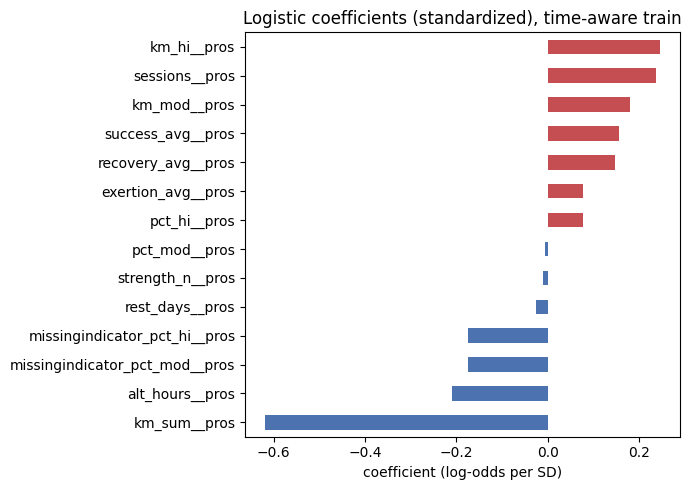

In [8]:
m = logit_pipe(C=0.1)
m.fit(ta_train[FEATS], ta_train.injury)
imp_names = list(m.named_steps['impute'].get_feature_names_out(FEATS))
coefs = pd.Series(m.named_steps['clf'].coef_[0], index=imp_names).sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
coefs.plot.barh(ax=ax, color=np.where(coefs < 0, '#4C72B0', '#C44E52'))
ax.set_title('Logistic coefficients (standardized), time-aware train')
ax.set_xlabel('coefficient (log-odds per SD)')
plt.tight_layout()

## Summary

- v1's 0.987 AUC diagnosed as a dataset-construction leak (publisher's >= 22-day
  pre-injury row buffer) and killed; features rebuilt symmetric in 02.
- Splits with leakage countermeasures: 7-day purge at time boundaries,
  deterministic injury-sorted athlete assignment, GroupKFold selection. Test sides
  locked for 04.
- Imbalance comparison + small grids on validation only; winners by the
  pre-registered AP rule, saved to `data/processed/model_selection.json`.
- 04 refits the winners on dev data and runs the full evaluation battery
  (PR/ROC, calibration, alert budget, subgroups) on the locked test sets.